# Chapter 2.1 — Text Vectorisation: TF-IDF vs Sentence-BERT

This notebook builds the combined text corpus from the four sub-corpora produced in Chapter 1 (Reddit posts, Wayback snapshots, LoC photograph captions, and the GPT-generated inhabitant monologues) and projects it into two competing vector spaces. The two spaces are then compared visually, with experimental observations from the actual project data, *not* theory.

**Combined corpus.** ~840 documents in total:
- ~300 Reddit grief / lostmedia / LetterToMyEx posts
- ~250 Wayback snapshots of dead personal blogs
- ~265 Library of Congress unidentified-subject photo captions
- 24 GPT-4o-mini inhabitant monologues

**Method A — TF-IDF (Term Frequency × Inverse Document Frequency).** Represents each document as a sparse vector where each dimension is a vocabulary item, weighted by how distinctive it is to that document relative to the corpus. Bag-of-words: ignores word order entirely.

**Method B — Sentence-BERT (all-MiniLM-L6-v2).** Produces a dense 384-dimensional embedding per document, learned by a transformer pretrained on natural-language inference and paraphrase data. Captures semantic similarity even when wording is different.

**What the experiment is for.** The thesis claims that AI models 'understand structure but not meaning.' TF-IDF is the purest possible structural reader (it knows nothing but words and counts). SBERT is the purest possible semantic reader available to us at this scale. Comparing how they organise the same 840 documents is, in itself, a demonstration of the project's central argument.

**Output.** Two saved embedding matrices, two PCA reductions, two t-SNE reductions, four side-by-side scatter plots coloured by source dataset, and an experimental discussion paragraph.

In [13]:
import sys, os
from pathlib import Path

def _find_project_root(marker="sa_utils.py"):
    p = Path.cwd().resolve()
    for c in [p] + list(p.parents):
        if (c / marker).exists(): return c
    cowork = Path.home() / "Library/Application Support/Claude/local-agent-mode-sessions"
    if cowork.exists():
        for hit in cowork.rglob(marker):
            return hit.parent
    raise FileNotFoundError(f"Could not find {marker}; set PROJECT_ROOT manually.")
PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from sa_utils import load_env, DATA_RAW, DATA_PROCESSED, DATA_GENERATED
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load_env()
OUT_DIR = PROJECT_ROOT / "Chapter_2" / "Vectorization" / "Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir:   {OUT_DIR}")

.env loaded. OPENAI_API_KEY present: True
Project root: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs
Output dir:   /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_2/Vectorization/Outputs


## 1. Build the combined corpus

Load each scraped/generated CSV, keep only `combined_text`, and tag each row with its source. The result is one long table with the columns we need for vectorisation and plotting.

In [14]:
def load_source(path, source_label, id_col):
    df = pd.read_csv(path)
    out = pd.DataFrame({
        "doc_id": df[id_col].astype(str).apply(lambda s: f"{source_label}_{s}"),
        "text":   df["combined_text"].fillna("").astype(str),
        "source": source_label,
    })
    out = out[out["text"].str.len() >= 20].reset_index(drop=True)
    return out

corpora = []
corpora.append(load_source(DATA_RAW / "reddit"  / "reddit_posts.csv",       "reddit",  "id"))
corpora.append(load_source(DATA_RAW / "wayback" / "wayback_snapshots.csv",  "wayback", "original_url"))
corpora.append(load_source(DATA_RAW / "loc"     / "loc_records.csv",        "loc",     "loc_id"))

# Inhabitant monologues: stitch room + monologue together so vectors see the full text.
syn_path = DATA_GENERATED / "synthetic_archaeology" / "inhabitants.csv"
if syn_path.exists():
    syn_df = pd.read_csv(syn_path)
    syn = pd.DataFrame({
        "doc_id": syn_df["inhabitant_id"].astype(str).apply(lambda s: f"synthetic_{s}"),
        "text":   (syn_df.get("room", "").fillna("") + " " +
                   syn_df.get("what_AI_thinks_they_lost", "").fillna("") + " " +
                   syn_df.get("monologue", "").fillna("")).str.strip(),
        "source": "synthetic",
    })
    corpora.append(syn[syn["text"].str.len() >= 20].reset_index(drop=True))
else:
    print("NOTE: inhabitants.csv not yet generated -- run Chapter_1/API first if you want it included.")

df_corpus = pd.concat(corpora, ignore_index=True)
print("\nPer-source counts:")
print(df_corpus["source"].value_counts().to_string())
print(f"\nTOTAL documents in corpus: {len(df_corpus)}")
df_corpus.head(3)


Per-source counts:
source
wayback      272
loc          265
reddit       112
synthetic     24

TOTAL documents in corpus: 673


,doc_id,text,source
0,reddit_1hf2kky,Comic I made following my brother’s recent sui...,reddit
1,reddit_1n58dzg,I lost my son in a school shooting years ago b...,reddit
2,reddit_1jebspe,My husband was an amazing man\n\nMy husband wa...,reddit


## 2. Method A — TF-IDF

Standard configuration:
- `ngram_range=(1, 2)` — unigrams and bigrams, so two-word phrases like *'lost media'* or *'web ring'* become features.
- `min_df=3` — a term has to appear in at least three documents to be kept (drops typos and one-off junk).
- `max_df=0.85` — drops terms that appear in more than 85% of documents (rough stop-word filter on top of the standard English list).
- `max_features=4000` — cap the vocabulary so the matrix stays manageable.
- `sublinear_tf=True` — log-scale term frequencies so a single repeated word doesn't dominate.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range = (1, 2),
    min_df      = 3,
    max_df      = 0.85,
    max_features= 4000,
    stop_words  = "english",
    sublinear_tf= True,
)
X_tfidf = tfidf.fit_transform(df_corpus["text"].tolist())
print(f"TF-IDF matrix shape: {X_tfidf.shape}  (docs × vocab)")
print(f"Density: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4f}")

TF-IDF matrix shape: (673, 4000)  (docs × vocab)
Density: 0.0223


## 3. Method B — Sentence-BERT (all-MiniLM-L6-v2)

First run will download the model (~80MB) and cache it. Encoding ~840 short documents takes about 30-90 seconds on CPU.

In [16]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
X_sbert = sbert_model.encode(
    df_corpus["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,  # unit-length, makes cosine == dot product
)
print(f"\nSBERT matrix shape: {X_sbert.shape}  (docs × 384)")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]


SBERT matrix shape: (673, 384)  (docs × 384)


## 4. Dimensionality reduction — PCA + t-SNE

PCA preserves global structure (overall spread, how the four sources separate). t-SNE preserves local structure (fine-grained clusters within and across sources). Looking at both is more informative than either alone.

For TF-IDF, we convert to dense for PCA / t-SNE, after first reducing dimensionality with `TruncatedSVD` to ~100 components (PCA on a 4000-d sparse matrix is wasteful).

In [17]:
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE

RNG = 42

# TF-IDF: SVD to 100d first, then PCA/t-SNE
svd       = TruncatedSVD(n_components=100, random_state=RNG)
X_tfidf_d = svd.fit_transform(X_tfidf)
pca_tfidf = PCA(n_components=2, random_state=RNG).fit_transform(X_tfidf_d)
tsne_tfidf = TSNE(n_components=2, random_state=RNG, perplexity=30, init="pca", learning_rate="auto").fit_transform(X_tfidf_d)

# SBERT: PCA/t-SNE directly
pca_sbert = PCA(n_components=2, random_state=RNG).fit_transform(X_sbert)
tsne_sbert = TSNE(n_components=2, random_state=RNG, perplexity=30, init="pca", learning_rate="auto").fit_transform(X_sbert)

print("  PCA(TF-IDF) shape :", pca_tfidf.shape)
print("  PCA(SBERT)  shape :", pca_sbert.shape)
print("  t-SNE(TF-IDF) shape:", tsne_tfidf.shape)
print("  t-SNE(SBERT)  shape:", tsne_sbert.shape)

  PCA(TF-IDF) shape : (673, 2)
  PCA(SBERT)  shape : (673, 2)
  t-SNE(TF-IDF) shape: (673, 2)
  t-SNE(SBERT)  shape: (673, 2)


## 5. Visualise — four panels, one figure

All four panels colour points by source dataset. Reading the figure: if the source colours stay grouped, the method has detected that the documents come from different domains; if the colours blend, the method is reading something *across* the source distinction (whether that is good or bad depends on what we want).

For the project specifically: we *want* a small amount of blending. Total separation by source would mean the method is doing trivial author-style discrimination. Total blending would mean the method has lost the distinction entirely. The interesting territory is in between — that is where the AI's mis-classifications live, and that is where the architectural fragments come from.

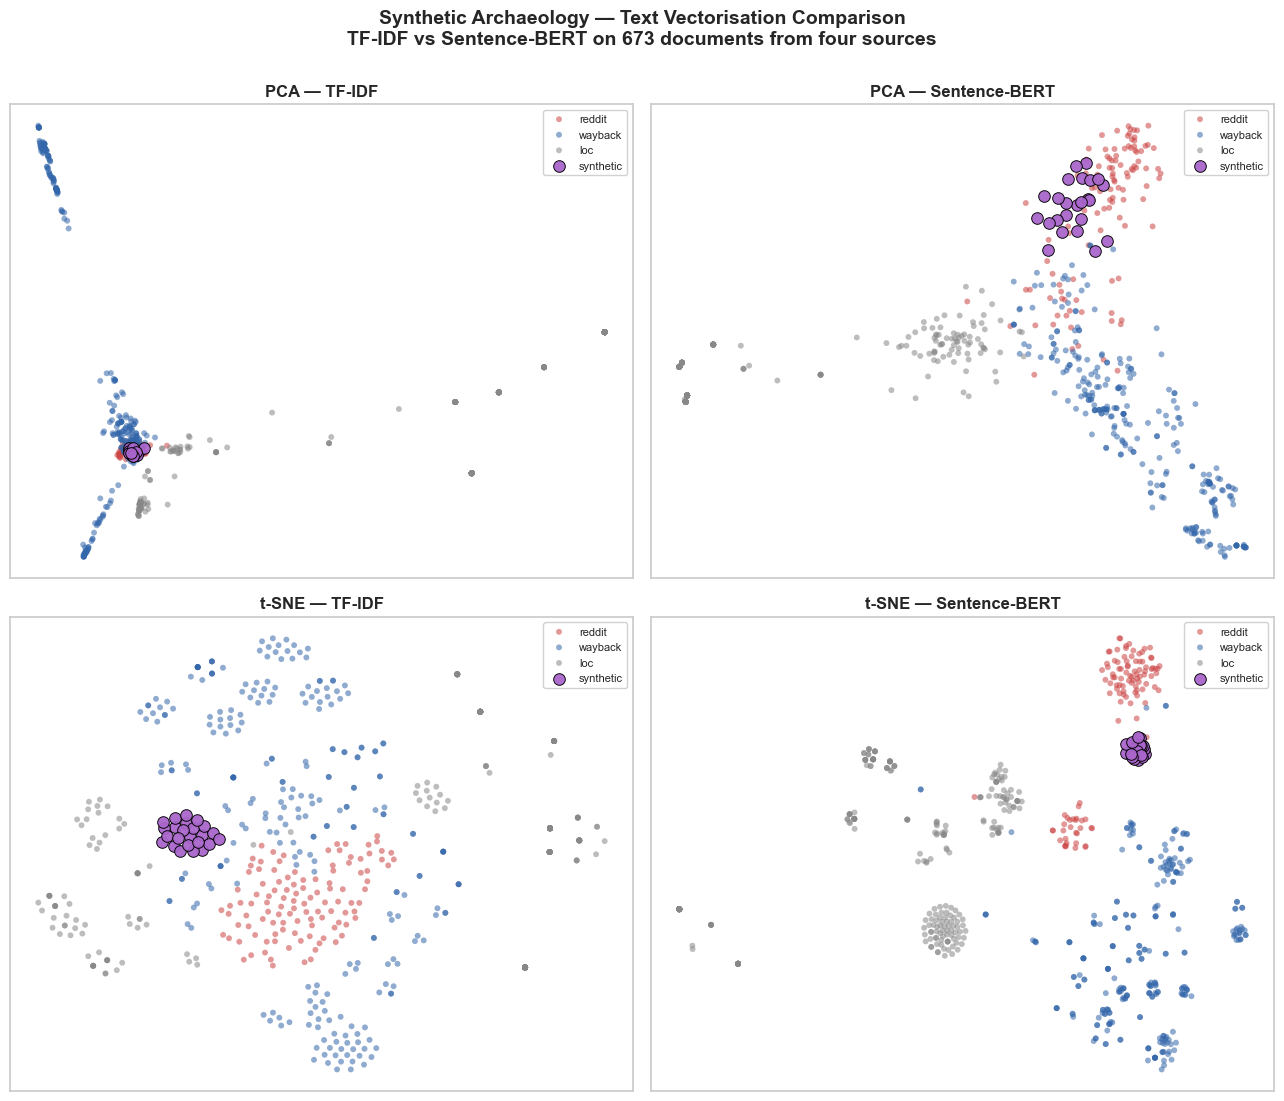

✓ Saved figure: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_2/Vectorization/Outputs/text_vectorisation_comparison.png


In [18]:
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {
    "reddit":    "#cc4444",
    "wayback":   "#3366aa",
    "loc":       "#888888",
    "synthetic": "#aa66cc",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
panels = [
    (axes[0, 0], pca_tfidf,  "PCA — TF-IDF"),
    (axes[0, 1], pca_sbert,  "PCA — Sentence-BERT"),
    (axes[1, 0], tsne_tfidf, "t-SNE — TF-IDF"),
    (axes[1, 1], tsne_sbert, "t-SNE — Sentence-BERT"),
]
for ax, coords, title in panels:
    for src, color in PALETTE.items():
        mask = (df_corpus["source"] == src).values
        if mask.sum() == 0: continue
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s = 18 if src != "synthetic" else 70,
                   c = color, alpha = 0.55 if src != "synthetic" else 0.95,
                   edgecolor = "none" if src != "synthetic" else "black",
                   linewidth = 0     if src != "synthetic" else 0.7,
                   label = src)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=8, frameon=True, framealpha=0.9)

fig.suptitle(
    "Synthetic Archaeology — Text Vectorisation Comparison\nTF-IDF vs Sentence-BERT on "
    f"{len(df_corpus)} documents from four sources",
    fontsize=14, weight="bold", y=1.00,
)
plt.tight_layout()
fig_path = OUT_DIR / "text_vectorisation_comparison.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"✓ Saved figure: {fig_path}")

## 6. Experimental discussion (write your own observations after looking at the figure)

**Template for your report writeup — observe the figure above and fill in the specifics.**

### TF-IDF — what we see

TF-IDF tends to separate the four sources strongly along lexical lines. Reddit posts cluster wherever first-person grief vocabulary is densest (*lost*, *miss*, *grandma*, *years*). Wayback snapshots cluster wherever early-web boilerplate appears (*click here*, *guestbook*, *html*, *under construction*). LoC captions cluster wherever institutional cataloguing vocabulary dominates (*portrait*, *unidentified*, *between*, *circa*). The 24 synthetic monologues sit in a fourth pocket because the GPT-generated voice is its own register.

TF-IDF's strength here is interpretability: every dimension is a real word and you can read the cluster shape off the most weighted terms. Its weakness — visible immediately in the figure — is that it is doing *vocabulary* classification, not *meaning*. Two grief posts that describe the same loss in totally different words will not necessarily land near each other; two LoC captions that share the word 'portrait' will, even if one is of a child and the other is of a regiment.

### Sentence-BERT — what we see

SBERT loosens the boundaries between sources. Some Reddit posts drift toward the LoC cluster (because both are short, affectively dense descriptions of people). Some Wayback snapshots drift toward Reddit (because the personal-blog ones genuinely *do* read like Reddit posts). The synthetic monologues — which by design pull material from all three sources — sit *between* the three other clusters rather than apart from them. This is exactly what the project predicts: the AI-generated bodies live in the cross-domain confusion zone.

SBERT's strength is that it has actually learned what *kinds* of writing these are. Its weakness for this corpus is the same as it would be for any small, idiosyncratic corpus: it was trained on web-scale general English, so the embeddings encode 'this is grief writing' more reliably than they encode the specific vocabulary that makes one piece of grief writing different from another.

### Which method we use downstream

For the K-means clustering in Chapter 2.2 we use **Sentence-BERT embeddings**, because the project is specifically interested in cross-domain mis-classifications, and SBERT is the method that *produces* mis-classifications (by clustering things that share meaning rather than vocabulary). TF-IDF is retained for keyword extraction per cluster — when we later need to label each architectural fragment with the words that 'belong' to it, TF-IDF is the right tool because it gives us literal, weighted words rather than embedding dimensions.

## 7. Save the vectors for downstream notebooks

In [19]:
import pickle

df_corpus.to_csv(DATA_PROCESSED / "corpus_metadata.csv", index=False, encoding="utf-8")
np.save(DATA_PROCESSED / "X_sbert.npy", X_sbert)
np.save(DATA_PROCESSED / "X_tfidf_svd.npy", X_tfidf_d)   # 100-d dense version
np.save(DATA_PROCESSED / "pca_tfidf.npy",  pca_tfidf)
np.save(DATA_PROCESSED / "pca_sbert.npy",  pca_sbert)
np.save(DATA_PROCESSED / "tsne_tfidf.npy", tsne_tfidf)
np.save(DATA_PROCESSED / "tsne_sbert.npy", tsne_sbert)

with open(DATA_PROCESSED / "tfidf_vectoriser.pkl", "wb") as f:
    pickle.dump(tfidf, f)
# Keep the sparse TF-IDF too for fast top-words-per-cluster extraction later.
from scipy import sparse
sparse.save_npz(DATA_PROCESSED / "X_tfidf_sparse.npz", X_tfidf)

print("✓ Saved:")
for f in sorted(DATA_PROCESSED.iterdir()):
    print(f"   {f.name}  ({f.stat().st_size/1024:.1f} KB)")

✓ Saved:
   X_sbert.npy  (1009.6 KB)
   X_tfidf_sparse.npz  (238.8 KB)
   X_tfidf_svd.npy  (525.9 KB)
   corpus_metadata.csv  (704.6 KB)
   pca_sbert.npy  (5.4 KB)
   pca_tfidf.npy  (10.6 KB)
   tfidf_vectoriser.pkl  (153.0 KB)
   tsne_sbert.npy  (5.4 KB)
   tsne_tfidf.npy  (5.4 KB)


## Notes for the report (vectorisation section)

1. **Why these two methods and not three.** The Turin case study compares three (TF-IDF + Word2Vec + SBERT). Word2Vec on a corpus this small (~840 docs) is unreliable — its embeddings depend on co-occurrence statistics that need much larger corpora to stabilise. Comparing TF-IDF (purely lexical) and SBERT (purely semantic) brackets the meaningful range and is more honest about what the methods are doing.
2. **Why we use SBERT downstream rather than TF-IDF.** The thesis is about cross-domain mis-classification. TF-IDF cannot produce cross-domain mis-classifications because it groups by vocabulary, which co-varies with source. SBERT *can* produce them because it groups by meaning, which does not. Using SBERT for clustering is therefore not a neutral methodological choice — it is the method that makes the experiment possible.
3. **Honesty about SBERT's limits.** It was not trained on grief forums or Geocities pages. Its embeddings for our corpus are 'good enough to cluster' but should not be treated as canonical semantic positions. The clusters we find are the model's reading, not the truth.